# Categorical Encoding and Feature Scaling

Machine learning algorithms generally require numerical input, so categorical variables must be encoded. Additionally, scaling is used to give equal importance to features with different ranges. This notebook covers:
*   **One-Hot Encoding:** For nominal categories (creating binary columns).
*   **Label & Ordinal Encoding:** For ordered categories.
*   **Target Encoding:** High-cardinality feature encoding.
*   **Feature Scaling:** MinMaxScaler and StandardScaler.
*   **Practice Application:** Fit/Transform flow on Train/Test splits.

In [3]:
import pandas as pd
import numpy as np

In [2]:
# df=pd.DataFrame({
#     'size':['big','small','medium'],
#     'color':['yellow','red','black'],
#     'type':['normal','sports','casual'],
#     'price':[3000,4000,5000]
# })

In [3]:
# df

In [4]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder,TargetEncoder
#from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
n_rows=1000
data={
    'color':np.random.choice(['red','blue','green'],n_rows),
    'size':np.random.choice(['large','small','medium'],n_rows),
    'material':np.random.choice(['plastic','metal','wood'],n_rows),
    'price':np.random.randint(10,500,n_rows)
}

In [6]:
df=pd.DataFrame(data)

In [7]:
df.head(100)


,color,size,material,price
0,red,medium,wood,343
1,blue,small,wood,71
2,red,medium,metal,167
3,green,medium,wood,257
4,green,large,plastic,51
...,...,...,...,...
95,green,small,metal,409
96,blue,small,wood,117
97,blue,medium,plastic,491
98,red,large,metal,205


In [8]:
x=df.drop(columns='price')
y=df.price
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [9]:
label_encoder=LabelEncoder()

* ### updated_xtrain=label_encoder.fit_transform(xtrain)
* '''ValueError: y should be a 1d array, 
* got an array of shape (800, 3) instead.'''

In [10]:
# updated_xtrain=label_encoder.fit_transform(xtrain)
'''ValueError: y should be a 1d array, 
got an array of shape (800, 3) instead.'''

'ValueError: y should be a 1d array, \ngot an array of shape (800, 3) instead.'

In [11]:
label_encoder.fit_transform(xtrain['color'])

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 2, 2, 2, 1, 2, 0, 0, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2,
       0, 0, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0, 1,
       2, 0, 1, 2, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 2, 1, 2, 2, 1, 2,
       2, 2, 2, 2, 0, 2, 1, 2, 0, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 0, 0, 1,
       1, 2, 0, 2, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1,
       0, 0, 1, 0, 0, 2, 1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 2, 1, 1, 2, 2, 1,
       2, 2, 1, 2, 1, 2, 1, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 1, 1, 1,
       2, 1, 0, 0, 1, 0, 2, 1, 1, 0, 1, 0, 1, 1, 2, 2, 0, 1, 2, 0, 2, 1,
       0, 2, 1, 1, 1, 2, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1, 0, 2, 1, 2,
       2, 2, 1, 2, 1, 1, 1, 0, 0, 0, 2, 1, 1, 1, 2, 1, 1, 0, 0, 1, 0, 1,
       2, 0, 0, 1, 0, 2, 1, 1, 0, 1, 1, 2, 1, 0, 2, 2, 1, 0, 2, 1, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 1,

In [12]:
new_input=['red','red']
label_encoder.transform(new_input)

array([2, 2])

# One Hot Encoding

In [27]:
# encoder=OneHotEncoder()  values=values.toarray()
encoder=OneHotEncoder(sparse_output=False)


In [28]:
updated_xtrain=encoder.fit_transform(xtrain)

In [29]:
encoder.transform(xtest[['color','size']]) 

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- material


''' ValueError: The feature names should match those that were passed during fit.
                                                            Feature names seen at fit time, yet now missing:
                                                                        - material '''

In [30]:
encoder.transform(xtest) # Valid  why xtest is 2-D

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [17]:
encoder.get_feature_names_out()

array(['color_blue', 'color_green', 'color_red', 'size_large',
       'size_medium', 'size_small', 'material_metal', 'material_plastic',
       'material_wood'], dtype=object)

In [31]:
columns=['color_blue', 'color_green', 'color_red', 'size_large',
       'size_medium', 'size_small', 'material_metal', 'material_plastic',
       'material_wood']

In [32]:
pd.DataFrame(values,columns=columns)

NameError: name 'values' is not defined

In [33]:
# new_input=[['red','large'],['blue','small']]
# encoder.transform(new_input)--error(see down)

 * ValueError: X has 2 features, but OneHotEncoder is expecting 3 features as input.

In [21]:
new_input=[['red','large','plastic'],['blue','small','wood']]
encoder.transform(new_input)

c:\Users\Aditya Sarapure\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 0., 1., 1., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1., 0., 0., 1.]])

In [22]:
# new_input=[['red1','large','plastic'],['blue','small','wood']]
# encoder.transform(new_input)--error() for new input

 * ValueError: Found unknown categories ['red1'] in column 0 during transform

In [36]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')


In [37]:
new_input=[['red1','large','plastic'],['blue','small','wood']]
encoder.transform(new_input)

NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [34]:
encoder.get_feature_names_out()

array(['color_blue', 'color_green', 'color_red', 'size_large',
       'size_medium', 'size_small', 'material_metal', 'material_plastic',
       'material_wood'], dtype=object)

## objname.fit_transform(xtrain)
## objname.transform(xtest)

# Ordinal encoder

In [40]:
xtrain

,color,size,material
29,green,large,metal
535,green,medium,metal
695,green,large,plastic
557,green,large,plastic
836,green,small,wood
...,...,...,...
106,red,small,wood
270,green,small,metal
860,green,large,metal
435,blue,large,wood


In [44]:
from sklearn.preprocessing import OrdinalEncoder
or_encoder=OrdinalEncoder()
or_updated_xtrain=or_encoder.fit_transform(xtrain)
or_updated_xtrain


array([[1., 0., 0.],
       [1., 1., 0.],
       [1., 0., 1.],
       ...,
       [1., 0., 0.],
       [0., 0., 2.],
       [0., 0., 1.]])

* or_encoder.fit_transform(xtrain['color'])   
* ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'>      instead. Pass a DataFrame containing a single row (i.e. single sample) or a    single   column (i.e. single feature) instead.


In [48]:
or_updated_xtest=or_encoder.transform(xtest)
or_updated_xtest

c:\Users\Aditya Sarapure\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(


array([[2., 1., 2.],
       [1., 2., 1.],
       [2., 2., 2.],
       [1., 2., 2.],
       [1., 0., 1.],
       [1., 2., 0.],
       [0., 1., 0.],
       [2., 2., 0.],
       [0., 2., 2.],
       [1., 1., 0.],
       [0., 1., 0.],
       [0., 2., 2.],
       [2., 2., 1.],
       [0., 0., 1.],
       [2., 2., 2.],
       [0., 0., 0.],
       [2., 2., 2.],
       [1., 1., 2.],
       [0., 1., 2.],
       [1., 1., 2.],
       [2., 1., 2.],
       [1., 0., 1.],
       [0., 0., 0.],
       [0., 1., 0.],
       [2., 0., 1.],
       [2., 2., 2.],
       [0., 2., 2.],
       [0., 2., 0.],
       [0., 0., 0.],
       [1., 2., 1.],
       [1., 0., 1.],
       [0., 1., 2.],
       [2., 1., 1.],
       [0., 1., 2.],
       [1., 0., 1.],
       [0., 0., 0.],
       [2., 2., 0.],
       [1., 1., 1.],
       [1., 1., 0.],
       [1., 2., 2.],
       [2., 1., 0.],
       [0., 2., 2.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 2., 1.],
       [1., 0., 1.],
       [1., 2., 2.],
       [1., 1

* or_encoder.transform(xtest['color'])   
* ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


In [51]:
df.value_counts()

color  size    material  price
green  large   metal     466      3
red    small   wood      70       3
blue   medium  wood      44       3
       large   wood      224      3
       small   plastic   357      2
                                 ..
green  large   metal     401      1
                         427      1
                         428      1
                         432      1
red    small   wood      498      1
Name: count, Length: 956, dtype: int64

* new_input=[['red1','large','plastic'],['blue','small1','wood']]   
* or_encoder.transform(new_input)   
* ValueError: Found unknown categories ['red1'] in column 0 during transform

# Handling unknown value in ordinal encoder

In [54]:
error_or_encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
updated_xtrain=error_or_encoder.fit_transform(xtrain)
updated_xtest=error_or_encoder.transform(xtest)

In [55]:
new_data=[['white','small','wood'],['red','small','wood']]
newinput_updated=error_or_encoder.transform(new_data)


c:\Users\Aditya Sarapure\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


In [57]:
df.columns

Index(['color', 'size', 'material', 'price'], dtype='object')

In [58]:
new_data1=pd.DataFrame(data=[['white','small','wood'],['red','small','wood']],columns=['color','size','material'])

In [59]:
newinput_updated1=error_or_encoder.transform(new_data1)

In [43]:
import pandas as pd
df=pd.read_csv("collegePlace.csv")

In [44]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [45]:
X=df.drop(columns='PlacedOrNot')
y=df['PlacedOrNot']


In [63]:
num_cols=X.select_dtypes(include='number')
obj_cols=X.select_dtypes(include='object')

In [64]:
num_cols

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs
0,22,1,8,1,1
1,21,0,7,1,1
2,22,1,6,0,0
3,21,0,8,0,1
4,22,0,8,1,0
...,...,...,...,...,...
2961,23,0,7,0,0
2962,23,1,7,1,0
2963,22,1,7,0,0
2964,22,1,7,0,0


<Axes: >

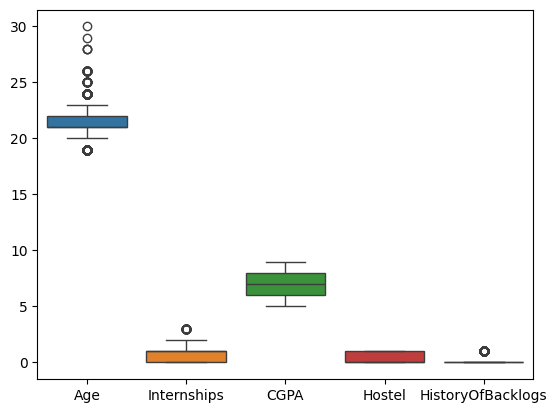

In [65]:
import seaborn as sns
sns.boxplot(df[["Age","Internships","CGPA","Hostel","HistoryOfBacklogs"]])

In [85]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [67]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [68]:
scaling=MinMaxScaler()
label_encoder=LabelEncoder()

In [69]:
xtrain

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs
2458,19,Male,Mechanical,1,8,1,0
509,21,Male,Information Technology,0,7,0,0
1370,21,Male,Information Technology,0,7,0,1
1352,26,Male,Computer Science,1,7,0,0
1779,23,Male,Electrical,1,8,0,0
...,...,...,...,...,...,...,...
1638,22,Male,Computer Science,3,8,0,0
1095,22,Male,Computer Science,1,6,0,0
1130,22,Female,Civil,1,8,0,0
1294,22,Male,Computer Science,0,7,0,0


In [74]:
xtrain[num_cols]=scaling.fit_transform(xtrain[['Age','Internships','CGPA','Hostel','HistoryOfBacklogs']])

TypeError: Must pass DataFrame or 2-d ndarray with boolean values only

In [71]:
xtrain[obj_cols]=label_encoder.fit_transform(xtrain[obj_cols])

ValueError: Boolean array expected for the condition, not object

In [81]:
values=encoder.fit_transform(xtrain[obj_cols])

ValueError: Boolean array expected for the condition, not object

In [ ]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
cols=encoder.get_feature_names_out()


ValueError: Boolean array expected for the condition, not object

In [84]:
xtrain[cols]=values
xtrain.drop(columns=['Extracurricular Activities '],inplace=True)
xtrain

NameError: name 'values' is not defined

In [ ]:
xtest[num_cols]=scaling.transform(xtest[num_cols])
xtest_values=encoder.transform(xtest[obj_cols])
xtest[cols]=xtest_values
xtest.drop(columns=['Extracurricular Activities'],inplace=True)



In [86]:
model=LinearRegression()

In [ ]:
model.fit(xtrain,ytrain)

In [ ]:
model.score(xtest,ytest)

---
## 🛠️ Additional Practice: Encoding & Scaling Workflows

*(This section contains consolidated scaling practices from `enocode_gpt.ipynb`)*

In [6]:
# Read Dataset.
df = pd.read_csv("Scaling_Encoding_Practice_Dataset.csv")

# Display Dataset
print(df.head())

  Customer_ID  Age  Annual_Income  Spending_Score  Experience_Years  \
0        C001   22          25000              82                 1   
1        C002   35          65000              45                10   
2        C003   29          42000              71                 5   
3        C004   41          90000              32                15   
4        C005   24          31000              88                 2   

        City  Gender Education Marital_Status Purchased Preferred_Device  
0  Bengaluru    Male  Bachelor         Single       Yes           Mobile  
1     Mysuru  Female    Master        Married        No           Laptop  
2      Hubli    Male  Bachelor         Single       Yes           Tablet  
3   Belagavi  Female       PhD        Married        No           Laptop  
4  Bengaluru  Female  Bachelor         Single       Yes           Mobile  


In [7]:
# Separate Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# Drop Customer_ID
X = X.drop("Customer_ID", axis=1)

# -----------------------------
# LABEL ENCODING
# -----------------------------

le = LabelEncoder()

X["Gender"] = le.fit_transform(X["Gender"])
X["Marital_Status"] = le.fit_transform(X["Marital_Status"])

y = le.fit_transform(y)

In [8]:
X["Marital_Status"]

0     1
1     0
2     1
3     0
4     1
5     0
6     1
7     0
8     0
9     1
10    0
11    0
12    1
13    0
14    1
15    0
16    0
17    1
18    0
19    0
Name: Marital_Status, dtype: int32

In [9]:
# -----------------------------
# ONE HOT ENCODING
# -----------------------------

X = pd.get_dummies(
    X,
    columns=["City", "Education", "Preferred_Device"],
    dtype=int
)


In [10]:
# -----------------------------
# STANDARD SCALING
# -----------------------------

sc = StandardScaler()

numerical_columns = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Experience_Years"
]

X[numerical_columns] = sc.fit_transform(X[numerical_columns])

print("\nData after Standard Scaling")
print(X.head())



Data after Standard Scaling
        Age  Annual_Income  Spending_Score  Experience_Years  Gender  \
0 -1.299043      -1.211027        1.018568         -1.140557       1   
1  0.150533       0.063738       -0.634371          0.012815       0   
2 -0.518502      -0.669252        0.527154         -0.627947       1   
3  0.819568       0.860466       -1.215134          0.653578       0   
4 -1.076032      -1.019812        1.286612         -1.012405       0   

   Marital_Status  City_Belagavi  City_Bengaluru  City_Hubli  City_Mangaluru  \
0               1              0               1           0               0   
1               0              0               0           0               0   
2               1              0               0           1               0   
3               0              1               0           0               0   
4               1              0               1           0               0   

   City_Mysuru  Education_Bachelor  Education_Master  Edu

In [11]:
# -----------------------------
# MIN MAX SCALING
# -----------------------------

df2 = pd.read_csv("Scaling_Encoding_Practice_Dataset.csv")

X2 = df2.drop(["Purchased", "Customer_ID"], axis=1)
y2 = df2["Purchased"]

le = LabelEncoder()

X2["Gender"] = le.fit_transform(X2["Gender"])
X2["Marital_Status"] = le.fit_transform(X2["Marital_Status"])

X2 = pd.get_dummies(
    X2,
    columns=["City", "Education", "Preferred_Device"],
    dtype=int
)

mm = MinMaxScaler()

X2[numerical_columns] = mm.fit_transform(X2[numerical_columns])

print("\nData after Min-Max Scaling")
print(X2.head())


Data after Min-Max Scaling
        Age  Annual_Income  Spending_Score  Experience_Years  Gender  \
0  0.032258       0.025424        0.831169          0.035714       1   
1  0.451613       0.364407        0.350649          0.357143       0   
2  0.258065       0.169492        0.688312          0.178571       1   
3  0.645161       0.576271        0.181818          0.535714       0   
4  0.096774       0.076271        0.909091          0.071429       0   

   Marital_Status  City_Belagavi  City_Bengaluru  City_Hubli  City_Mangaluru  \
0               1              0               1           0               0   
1               0              0               0           0               0   
2               1              0               0           1               0   
3               0              1               0           0               0   
4               1              0               1           0               0   

   City_Mysuru  Education_Bachelor  Education_Master  Educ

In [13]:
# Train Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Scores
print("Training Score :", model.score(X_train, y_train))
print("Testing Score :", model.score(X_test, y_test))

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)

NameError: name 'X_train' is not defined